In [1]:
"""Smoke-test for the NEW Rossmann forecasting pipeline (hypertuning).

Runs the full feature-engineering -> target-transform -> inner-CV objective and
refit flow on a few real stores, then exercises hypertuning.optimize end-to-end
to validate the updated TimeSeriesCV(n_splits, train_size, test_size) API.
"""

import os
import logging
import warnings

import optuna
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

from src import features
from src.preprocessing import preprocess_data
from src.engine import hypertuning, utils
from src.engine.cv import TimeSeriesCV
from src.engine.target_transformer import TargetTransformer
from src.settings import AppSettings

config = AppSettings.from_yaml('./config.yaml')

os.makedirs(config.path.log_dir, exist_ok=True)
assert os.path.exists(config.path.data_dir), \
    f"Data directory {config.path.data_dir} does not exist."

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    filename=config.path.logs,
                    format="%(levelname)s  %(message)s")

logger = logging.getLogger(__name__)

def plot_actual_vs_predicted(results, n_days_to_plot, n_days_offset):
        
    max_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
    min_date = max_date - pd.Timedelta(days=n_days_to_plot)

    actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
    preds_recent   = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

    plot_stores = actuals_recent.index.get_level_values("Store").unique()

    fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

    for i, store in enumerate(plot_stores):

        actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
        predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

        actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
        predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

        actual_store_sales.plot(label="Actual", ax=ax[i])
        predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

        ax[i].set_ylabel("Store {}".format(store))
        ax[i].set_xlabel("Date")

    plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days)".format(n_days_to_plot), fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
    plt.show()

c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config

`config` merges the CV and study settings so `hypertuning.optimize` can read the inner-CV keys (`n_inner_splits`, `inner_train_size`, `inner_test_size`) used by the new `TimeSeriesCV` API.

In [2]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """

sales = pd.read_csv(config.path.train)
stores = pd.read_csv(config.path.stores)

stores_to_use = [1, 2, 3]
stores = stores[stores['Store'].isin(stores_to_use)]

df = preprocess_data(sales, stores)

# Feature engineering + target transform (new pipeline)

In [3]:
y = df.set_index(['Store', 'Date'])['Sales']

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: features.compute(df, config.feature_engineering, config.horizon)))

trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-config.horizon.days),
                        anchor_col='lag_days_0')
trf.fit(X)

y = trf.transform(y)    # forward difference target
X = X.loc[y.index]      # align features with target
X['subdivision'] = X['subdivision'].astype('category')  # convert subdivision to categorical dtype
X['holiday_name'] = X['holiday_name'].astype('category')  # convert holiday_name to categorical dtype

X.dtypes

# TODO: Extend holiday name according to the waves (sigma). Not only on the exact date of the holiday

lag_days_0                       float64
lag_days_1                       float64
lag_days_2                       float64
lag_days_3                       float64
lag_days_4                       float64
lag_days_5                       float64
lag_days_6                       float64
lag_days_7                       float64
lag_days_8                       float64
lag_days_9                       float64
lag_days_10                      float64
lag_days_11                      float64
lag_days_12                      float64
lag_days_13                      float64
lag_days_14                      float64
lag_weeks_3                      float64
lag_weeks_4                      float64
lag_months_2                     float64
lag_months_3                     float64
lag_months_4                     float64
lag_months_5                     float64
lag_months_6                     float64
lag_years_1                      float64
diff_days_1                      float64
diff_days_2     

In [ ]:

from src.features.from_calendar import calendar
from src.features.from_target import lag_features, diff_features, rolling_features
from src.features.from_store import days_with_competition, days_in_promotion
from src.features.from_holidays import holiday_waves, subdivision, holiday_names

import numpy as np

horizon = pd.DateOffset(days=config.horizon.days)

grouped = df.set_index(['Date']).groupby('Store')

for _, group in grouped:

    log_sales = np.log1p(group['Sales'])  # Log-transform the sales to stabilize variance

    # This returns a string, so we will add it to the features dataframe at the end.
    subdiv = subdivision(group['isStateHoliday'].reset_index(),
                         country=config.feature_engineering.holidays["country"],
                         language=config.feature_engineering.holidays["language"],
                         index_name=group.index.name)  # Determine the subdivision based on holiday data

    features = [
        # Past features - these are aligned with the current date as they depend on past data
        lag_features(log_sales, lags=config.feature_engineering.lags),
        diff_features(log_sales, diffs=config.feature_engineering.diffs),
        rolling_features(log_sales, windows=config.feature_engineering.windows, agg_func='mean'),

        # Future features - these are aligned with the forecast horizon date as they are known in advance
        calendar(group.index.to_series() + horizon),
        days_with_competition(group['CompetitionStartDate'], offset=horizon),
        holiday_waves(group['isStateHoliday'], offset=horizon, sigma=config.feature_engineering.holidays["sigma"]),
        holiday_names(group.index.to_series(),
                      country=config.feature_engineering.holidays["country"],
                      language=config.feature_engineering.holidays["language"],
                      subdivision=subdiv,
                      offset=horizon),
        days_in_promotion(group['Promo'], offset=horizon),
        days_in_promotion(group['Promo2'], offset=horizon)
    ]

    features_df = pd.concat(features, axis=1)
    features_df["subdivision"] = subdiv # Now, add the subdivision for all rows.


    break


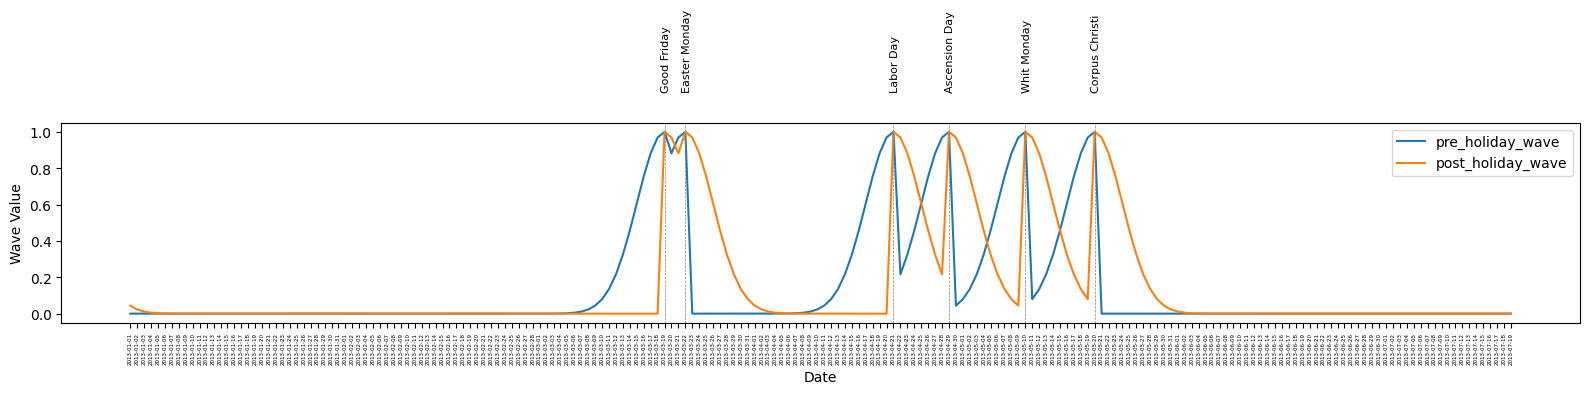

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 4))

# Prepare the data
gg = features_df[['pre_holiday_wave', 'post_holiday_wave', 'holiday_name']].reset_index().rename(columns={'index': 'Date'}).head(200)

# 1. Plot without specifying x. This forces the x-axis to be the integer index (0 to 199)
gg.plot(y=['pre_holiday_wave', 'post_holiday_wave'], kind='line', ax=ax, ylabel='Wave Value', xlabel='Date')

# Annotate using the integer index (idx) for the x-coordinate
for idx, row in gg.iterrows():
    if pd.notnull(row['holiday_name']):
        # Use idx instead of row['Date'] so it matches the 0-199 numerical axis
        ax.annotate(str(row['holiday_name']), (idx, row['pre_holiday_wave']), textcoords="offset points", xytext=(1,30), ha='center', fontsize=8, rotation=90)
        ax.axvline(x=idx, color='gray', linestyle='--', linewidth=0.5)

# 2. Use the integer index positions for the tick placements
ax.set_xticks(gg.index)

# 3. Format the Date objects to strings for the labels so Matplotlib doesn't look at their data type
date_labels = pd.to_datetime(gg['Date']).dt.strftime('%Y-%m-%d')
ax.set_xticklabels(date_labels, rotation=90, fontsize=4)

plt.tight_layout()
plt.show()

In [44]:
2 * 4 ** 2

32

In [4]:
X.index.to_series()

Store  Date      
1      2013-01-01    (1, 2013-01-01 00:00:00)
       2013-01-02    (1, 2013-01-02 00:00:00)
       2013-01-03    (1, 2013-01-03 00:00:00)
       2013-01-04    (1, 2013-01-04 00:00:00)
       2013-01-05    (1, 2013-01-05 00:00:00)
                               ...           
3      2015-07-17    (3, 2015-07-17 00:00:00)
       2015-07-18    (3, 2015-07-18 00:00:00)
       2015-07-19    (3, 2015-07-19 00:00:00)
       2015-07-20    (3, 2015-07-20 00:00:00)
       2015-07-21    (3, 2015-07-21 00:00:00)
Length: 2796, dtype: object

# Single-trial smoke test of `_objective`

In [5]:
from optuna.trial import FixedTrial
from src.engine.hypertuning import _objective


num_days = X.index.get_level_values("Date").nunique()
cv_sizes = utils.compute_cv_sizes(num_days,
                                  config.horizon.days,
                                  config.cross_validation)

inner_cv = TimeSeriesCV(n_splits=config.cross_validation.n_inner_splits,
                        gap=config.horizon.days,
                        train_size=cv_sizes['inner_train'],
                        test_size=cv_sizes['inner_test'])

# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,
    'colsample_bytree': 1.0,
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}

mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                   study_name='stuff_new',
                                   config=config)

obj_fcn(mock_trial)

[0]	train-rmse:4.79616+0.00458	test-rmse:4.73305+0.01345
[100]	train-rmse:4.34264+0.00404	test-rmse:4.28290+0.01132
[200]	train-rmse:3.93226+0.00359	test-rmse:3.87543+0.00971
[300]	train-rmse:3.56104+0.00325	test-rmse:3.50684+0.00836
[400]	train-rmse:3.22511+0.00290	test-rmse:3.17334+0.00729
[500]	train-rmse:2.92120+0.00264	test-rmse:2.87176+0.00647
[600]	train-rmse:2.64621+0.00242	test-rmse:2.59889+0.00600
[700]	train-rmse:2.39742+0.00219	test-rmse:2.35168+0.00558
[800]	train-rmse:2.17238+0.00197	test-rmse:2.12805+0.00537
[900]	train-rmse:1.96880+0.00177	test-rmse:1.92582+0.00523
[1000]	train-rmse:1.78469+0.00155	test-rmse:1.74284+0.00514
[1100]	train-rmse:1.61824+0.00145	test-rmse:1.57721+0.00511
[1200]	train-rmse:1.46775+0.00140	test-rmse:1.42730+0.00503
[1300]	train-rmse:1.33181+0.00123	test-rmse:1.29167+0.00498
[1400]	train-rmse:1.20887+0.00115	test-rmse:1.16883+0.00486
[1500]	train-rmse:1.09794+0.00109	test-rmse:1.05771+0.00479
[1600]	train-rmse:0.99769+0.00103	test-rmse:0.95728+

np.float64(0.08464831273597685)

MAE: 409.04


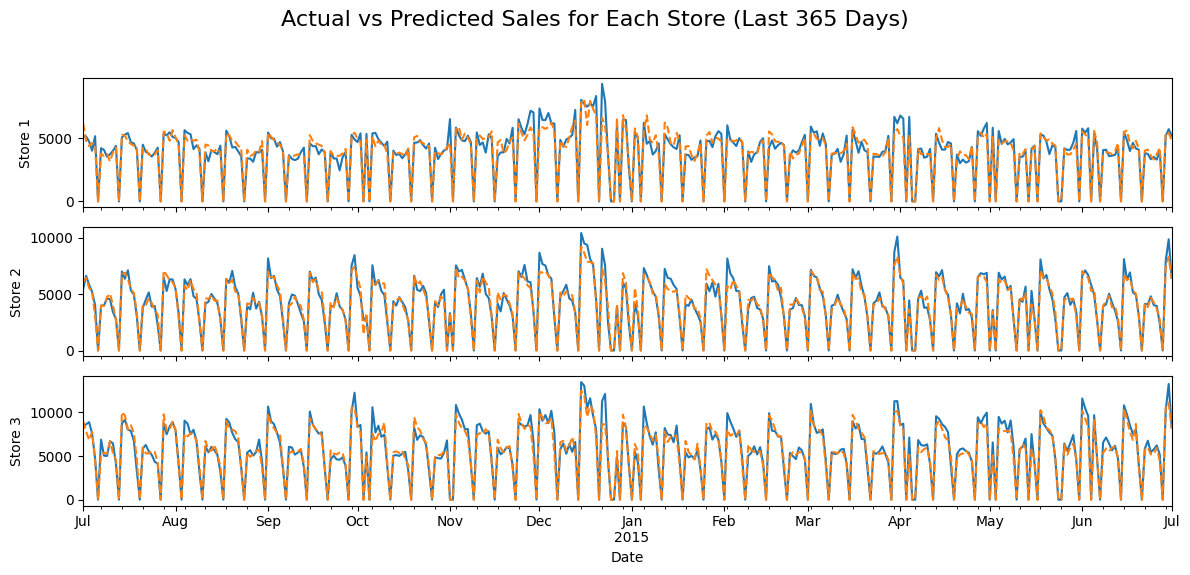

In [6]:
booster = utils.refit(X, y, mock_trial, config.model_constants)
actuals = df.set_index(['Store', 'Date'])['Sales']
preds   = utils.predict(X, booster, trf)
results = pd.merge(actuals, preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))
mae     = mean_absolute_error(results["Sales_actual"], results["Sales_predicted"])

print(f"MAE: {mae:.2f}")
plot_actual_vs_predicted(results, 365, 30)

# End-to-end `optimize`

Runs a couple of Optuna trials through the new `optimize`. Set `n_trials` small for a quick check.

[0]	train-rmse:4.78107+0.00459	test-rmse:4.71793+0.01342
[0]	train-rmse:4.79552+0.00459	test-rmse:4.73334+0.01240
[0]	train-rmse:4.78472+0.00460	test-rmse:4.72151+0.01351
[100]	train-rmse:3.41802+0.00332	test-rmse:3.34763+0.00787
[100]	train-rmse:4.28548+0.00381	test-rmse:4.28739+0.00180
[100]	train-rmse:3.17511+0.00322	test-rmse:3.10121+0.01662
[200]	train-rmse:2.45366+0.00243	test-rmse:2.37371+0.00375
[200]	train-rmse:3.83215+0.00311	test-rmse:3.89559+0.01461
[200]	train-rmse:2.12426+0.00202	test-rmse:2.04425+0.01947
[300]	train-rmse:1.77223+0.00166	test-rmse:1.68374+0.00109
[300]	train-rmse:3.42948+0.00256	test-rmse:3.53678+0.02381
[300]	train-rmse:1.44048+0.00136	test-rmse:1.35368+0.02571
[400]	train-rmse:1.29153+0.00107	test-rmse:1.19631+0.00102
[400]	train-rmse:3.07169+0.00201	test-rmse:3.21537+0.03530
[400]	train-rmse:0.99436+0.00074	test-rmse:0.90464+0.03343
[500]	train-rmse:0.95585+0.00090	test-rmse:0.85175+0.00244
[500]	train-rmse:2.75366+0.00165	test-rmse:2.92683+0.03940
[50

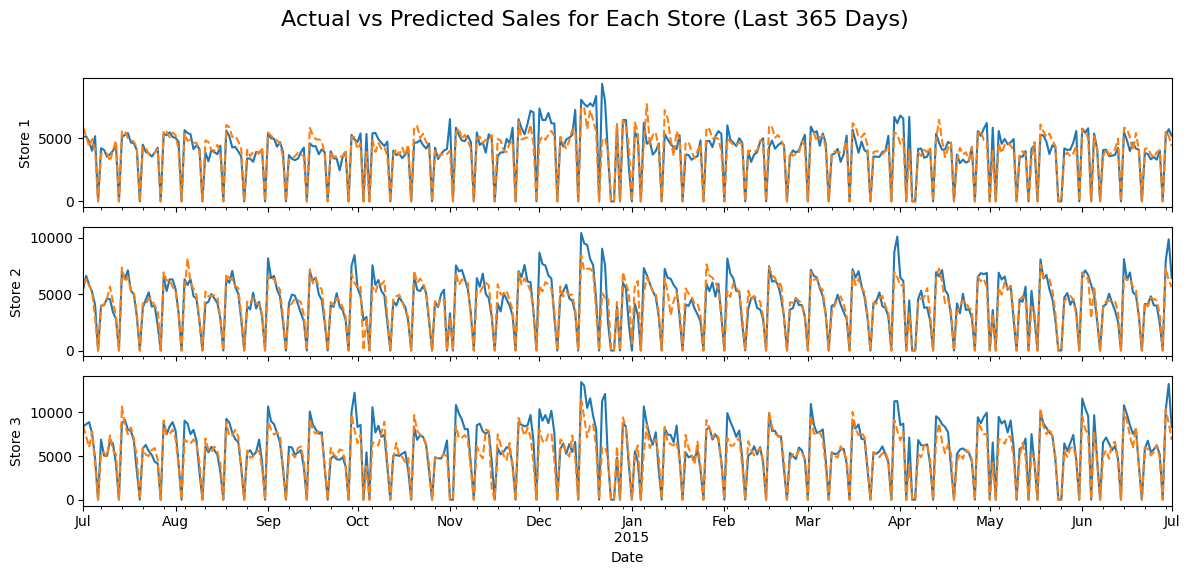

In [7]:
# get current timestamp
now = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
hypertuning.optimize(study_name=f'smoke_study_{now}',
                     X_train=X,
                     y_train=y,
                     cv_settings=cv_sizes,
                     config=config)

study = optuna.load_study(study_name=f'smoke_study_{now}',
                          storage=config.path.storage_url)

# Refit a model on the full dataset using the best hyperparameters
best_bst   = utils.refit(X, y, study.best_trial, config.model_constants)
best_preds = utils.predict(X, best_bst, trf)
actuals    = df.set_index(['Store', 'Date'])['Sales']
best_res   = pd.merge(actuals, best_preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))
best_mae   = mean_absolute_error(best_res["Sales_actual"], best_res["Sales_predicted"])

print(f"Best trial: #{study.best_trial.number}")
print(f"Best value ({config.model_constants.eval_metric}): {study.best_trial.value:.6f}")
print(f"Best params: {study.best_trial.params}")
print(f"Refit MAE: {best_mae:.2f}")
plot_actual_vs_predicted(best_res, 365, 30)

# Nested cross-validation (out-of-fold predictions)

Run 3 outer folds, each test window equal to `FORECAST_HORIZON` steps per store. On every outer fold we tune hyperparameters on the training portion, refit with the best params, and predict the held-out test window. The out-of-fold predictions are then collected and plotted per store.

In [ ]:
from sklearn.metrics import mean_absolute_error

num_days = X.index.get_level_values("Date").nunique()
cv_sizes = utils.compute_cv_sizes(num_days,
                                  config.horizon.days,
                                  config.cross_validation)

outer_cv = TimeSeriesCV(n_splits=config.cross_validation.n_outer_splits,
                        gap=config.horizon.days,
                        train_size=cv_sizes['outer_train'],
                        test_size=cv_sizes['outer_test'])

oof_preds = []
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):

    print(f"\n=== Outer fold {fold}/{config.cross_validation.n_outer_splits}")

    # Split the data into training and test sets for the current outer fold
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    # 1) Hyperparameter tuning on the outer-fold training data (embargoed inner CV inside optimize).
    study_name = f"nested_outer_{fold}"
    hypertuning.optimize(study_name=study_name,
                         X_train=X_train,
                         y_train=y_train,
                         cv_settings=cv_sizes,
                         config=config)

    # 2) Refit on the outer-fold training data using the best hyperparameters.
    study = optuna.load_study(study_name=study_name,
                              storage=config.path.storage_url)

    model = utils.refit(X_train, y_train, study.best_trial, config.model_constants)

    # 3) Predict the held-out test window and store the out-of-fold predictions.
    fold_preds = utils.predict(X_test, model, trf)  # Use the utility function to get predictions
    oof_preds.append(fold_preds)


# Combine all out-of-fold predictions and invert the target transform.
oof_results = pd.merge(left=df.set_index(['Store', 'Date'])['Sales'],
                       right=pd.concat(oof_preds),
                       left_index=True,
                       right_index=True,
                       suffixes=('_actual', '_predicted')).sort_index()


oof_mae = mean_absolute_error(oof_results["Sales_actual"], oof_results["Sales_predicted"])
print(f"\nOut-of-fold MAE: {oof_mae:.2f}")
plot_actual_vs_predicted(oof_results, 
                         n_days_to_plot=config.horizon.days * config.cross_validation.n_outer_splits, 
                         n_days_offset=0)